In [1]:
#installation and set up
%pip install -U spacy
!python -m spacy download en
!ppip install -U scikit-learn numpy pandas

Note: you may need to restart the kernel to use updated packages.
⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.5 MB/s  0:00:011.9 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
zsh:1: command not found: ppip


In [2]:
import matplotlib.pyplot as plt
import re
import spacy
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.model_selection import train_test_split

1. DATA EXPLORATORY ANALYSIS AND DATA CLEANING

In [3]:
#Imports and Load Data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
train_df.head()

Training set shape: (3200, 2)
Test set shape: (800, 1)


,content,category
0,The senator announced new taxation policy today.,politics
1,Market shows improvement following economic in...,business
2,The senator announced new education policy today.,politics
3,CEO announces strategic changes in logistics o...,business
4,New film release breaks box office records.,entertainment


In [4]:
# Check missing values
print("\n--- Missing Values Check ---")
print("Train missing values:\n", train_df.isnull().sum())
print("Test missing values:\n", test_df.isnull().sum())

# Check for duplicates
n_dupes = train_df.duplicated().sum()
print(f"\nDuplicate rows in Train: {n_dupes} out of {len(train_df)}")
print(f"Duplicate rows in Test: {test_df.duplicated().sum()}")

# NOTE: this dataset is built from a small set of sentence templates repeated many times
# (e.g. "The senator announced new X policy today"), so a high duplicate count is EXPECTED
# and NOT a data quality problem. We deliberately do NOT call drop_duplicates() here:
# doing so would shrink the training set from ~3200 rows down to ~150 unique sentences.



--- Missing Values Check ---
Train missing values:
 content     0
category    0
dtype: int64
Test missing values:
 content    0
dtype: int64

Duplicate rows in Train: 3048 out of 3200
Duplicate rows in Test: 665


Machine learning models usually require complete data.

In [5]:
print("Categories found:", train_df['category'].unique())
print()
print(train_df['category'].value_counts())


Categories found: ['politics' 'business' 'entertainment' 'technology' 'sports']

category
politics         654
technology       652
sports           639
entertainment    631
business         624
Name: count, dtype: int64


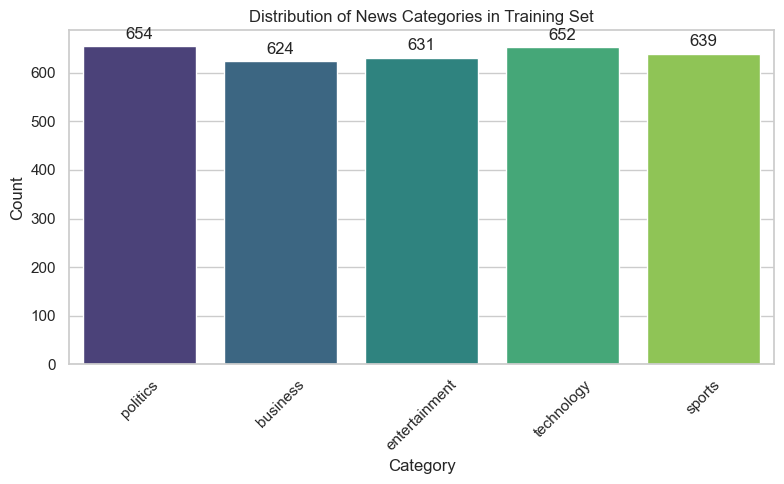

In [6]:
# Class Distribution Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_df,
    x="category",
    hue="category",  # Assign hue to the same variable
    palette="viridis",
    legend=False,  # Hide the redundant legend
)
plt.title("Distribution of News Categories in Training Set")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()

In [7]:
print(f"Original training set shape: {train_df.shape}")
print("\nCategory distribution in full training set:")
print(train_df["category"].value_counts(normalize=True) * 100)

Original training set shape: (3200, 2)

Category distribution in full training set:
category
politics         20.43750
technology       20.37500
sports           19.96875
entertainment    19.71875
business         19.50000
Name: proportion, dtype: float64


In [8]:
def clean_text(text):
    if pd.isna(text):
        return ""
    # Convert to string and lowercase
    text = str(text).lower()
    # Remove HTML tags if present
    text = re.sub(r"<.*?>", "", text)
    # Remove punctuation/special characters except standard alphanumeric and spaces
    text = re.sub(r"[^\w\s]", "", text)
    # Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [9]:
# Apply cleaning to content
train_df["cleaned_content"] = train_df["content"].apply(clean_text)
test_df["cleaned_content"] = test_df["content"].apply(clean_text)   # test set cleaned too: needed later for predictions

# Drop rows where content became empty after cleaning (only on train: the test set must stay complete,
# one prediction is expected per row for the final submission)
train_df = train_df[train_df["cleaned_content"] != ""]
print(f"Cleaned train shape: {train_df.shape}")
print(f"Cleaned test shape: {test_df.shape}")


Cleaned train shape: (3200, 3)
Cleaned test shape: (800, 2)


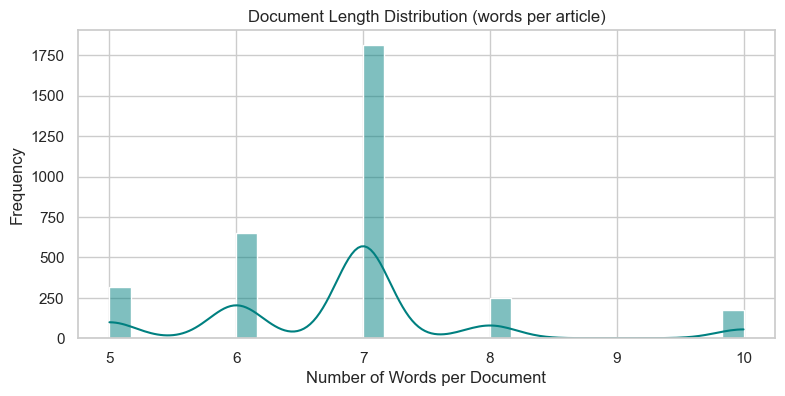

In [10]:
# Word Count per Document (statistical distribution: length)
train_df["word_count"] = train_df["cleaned_content"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(9, 4))
sns.histplot(train_df["word_count"], bins=30, kde=True, color="teal")
plt.title("Document Length Distribution (words per article)")
plt.xlabel("Number of Words per Document")
plt.ylabel("Frequency")
plt.show()


Vocabulary size: 141 unique words out of 21893 total tokens


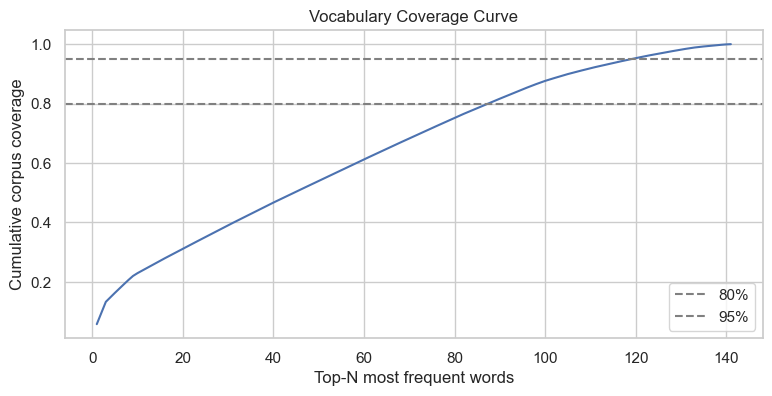

88 words cover 80% of the corpus (small/templated dataset -> low number is expected here).


In [11]:
# Vocabulary Coverage: how many unique words are needed to cover 80%/95% of the corpus
from collections import Counter
import numpy as np

all_tokens = " ".join(train_df["cleaned_content"]).split()
freq = Counter(all_tokens)
print(f"Vocabulary size: {len(freq)} unique words out of {len(all_tokens)} total tokens")

sorted_counts = np.array(sorted(freq.values(), reverse=True))
cum_coverage = np.cumsum(sorted_counts) / sorted_counts.sum()

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cum_coverage) + 1), cum_coverage)
plt.xlabel("Top-N most frequent words")
plt.ylabel("Cumulative corpus coverage")
plt.title("Vocabulary Coverage Curve")
plt.axhline(0.8, ls="--", c="grey", label="80%")
plt.axhline(0.95, ls="--", c="grey", label="95%")
plt.legend()
plt.show()

n80 = np.searchsorted(cum_coverage, 0.8) + 1
print(f"{n80} words cover 80% of the corpus "
      f"(small/templated dataset -> low number is expected here).")


In [12]:
print(train_df['cleaned_content'][0])

the senator announced new taxation policy today


In [13]:
#Perform Stratified Train/Validation Split
# test_size=0.2 means 80% for training and 20% for validation
train_data, val_data = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["category"]
)

print(f"\nNew Train split shape: {train_data.shape}")
print(f"New Validation split shape: {val_data.shape}")


New Train split shape: (2560, 4)
New Validation split shape: (640, 4)


In [14]:
# 4. Verify class proportions in both splits
print("\nTrain split category distribution (%):")
print(train_data["category"].value_counts(normalize=True) * 100)

print("\nValidation split category distribution (%):")
print(val_data["category"].value_counts(normalize=True) * 100)


Train split category distribution (%):
category
politics         20.429688
technology       20.390625
sports           19.960938
entertainment    19.726562
business         19.492188
Name: proportion, dtype: float64

Validation split category distribution (%):
category
politics         20.46875
technology       20.31250
sports           20.00000
entertainment    19.68750
business         19.53125
Name: proportion, dtype: float64


Using spaCy (as referenced in your NLP Introduction course material), you can extract part-of-speech (POS) tags, lemmas, and syntactic dependencies.

In [15]:
import sys

# 1. Aggiorniamo sia click che typer per farli andare d'accordo con spaCy
!{sys.executable} -m pip install -U "click>=8.2.1" "typer>=0.12.3"

# 2. Installiamo il modello usando il link diretto al file (aggirando l'errore 429)
!{sys.executable} -m pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

  Using cached en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)


In [16]:
nlp = spacy.load("en_core_web_sm")

# Function to extract linguistic features from a sample text
def extract_linguistic_features(text):
    doc = nlp(text)
    tokens_data = []
    for token in doc:
        tokens_data.append(
            {
                "Text": token.text,
                "Lemma": token.lemma_,
                "POS": token.pos_,
                "Tag": token.tag_,
                "Dependency": token.dep_,
                "Head": token.head.text,
            }
        )
    return pd.DataFrame(tokens_data)

# Test on a single headline from your dataset
sample_text = train_data["cleaned_content"].iloc[0]
print(f"Analyzing sample text: '{sample_text}'\n")
linguistic_df = extract_linguistic_features(sample_text)
linguistic_df

Analyzing sample text: 'researchers achieve milestone in cybersecurity advancement'



,Text,Lemma,POS,Tag,Dependency,Head
0,researchers,researcher,NOUN,NNS,nsubj,achieve
1,achieve,achieve,VERB,VBP,ROOT,achieve
2,milestone,milestone,NOUN,NN,dobj,achieve
3,in,in,ADP,IN,prep,achieve
4,cybersecurity,cybersecurity,NOUN,NN,compound,advancement
5,advancement,advancement,NOUN,NN,pobj,in


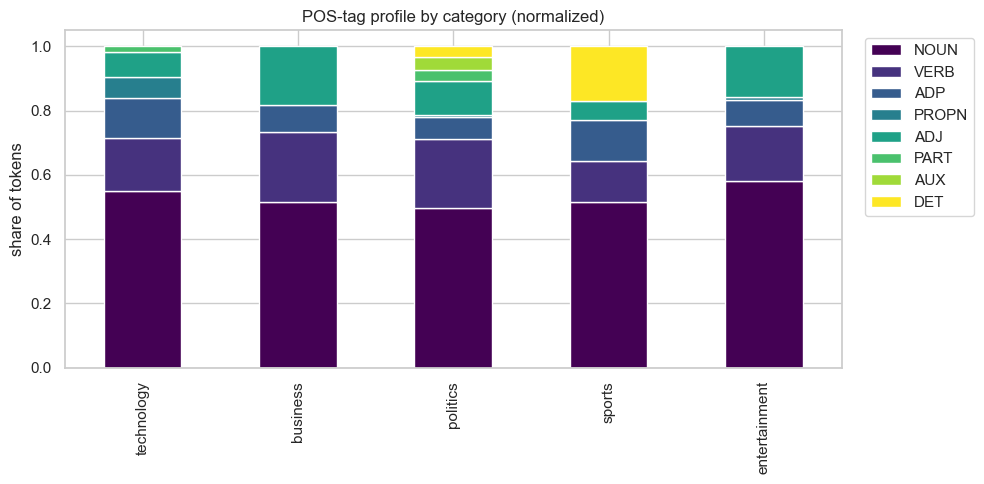

In [17]:
# Aggregate POS-tag profile across the whole (cleaned) training set, split by category
pos_by_category = {cat: Counter() for cat in train_data["category"].unique()}

for text, cat in zip(train_data["cleaned_content"], train_data["category"]):
    doc = nlp(text)
    for tok in doc:
        if tok.is_alpha:
            pos_by_category[cat][tok.pos_] += 1

pos_df = pd.DataFrame(pos_by_category).fillna(0)
pos_df_norm = pos_df.div(pos_df.sum(axis=0), axis=1)  # normalize per category (share of tokens)

pos_df_norm.T.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("POS-tag profile by category (normalized)")
plt.ylabel("share of tokens")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [18]:
# Dependency parsing visualization (the project explicitly asks for this, not just the table above)
from spacy import displacy

example_doc = nlp(train_data["cleaned_content"].iloc[0])
displacy.render(example_doc, style="dep", jupyter=True, options={"distance": 100})


In [19]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
from collections import Counter

MAX_VOCAB = 5000        # quante parole diverse "conosce" il modello al massimo
MAX_LEN = 20             # lunghezza fissa di ogni frase (in token)

# --- 1. COSTRUZIONE DEL VOCABOLARIO (Sostituisce il Tokenizer) ---

# Raccogliamo tutte le parole dal training set
all_words = " ".join(train_data["cleaned_content"]).split()
word_counts = Counter(all_words)

# Prendiamo le parole più frequenti (lasciando 2 spazi per il padding [0] e i termini sconosciuti <OOV> [1])
common_words = [word for word, count in word_counts.most_common(MAX_VOCAB - 2)]

# Creiamo un dizionario che associa ogni parola a un numero (partendo da 2)
word_index = {word: i + 2 for i, word in enumerate(common_words)}
word_index["<OOV>"] = 1 # 1 sarà il numero per tutte le parole non nel vocabolario

# --- 2. TRASFORMAZIONE IN SEQUENZE (Sostituisce texts_to_sequences) ---

def text_to_sequence(text):
    # Se la parola è nel vocabolario prende il suo numero, altrimenti prende 1 (<OOV>)
    return [word_index.get(word, 1) for word in text.split()]

X_train_seq = [text_to_sequence(text) for text in train_data["cleaned_content"]]
X_val_seq = [text_to_sequence(text) for text in val_data["cleaned_content"]]

# --- 3. PADDING (Sostituisce pad_sequences) ---

def pad_sequences_custom(sequences, maxlen):
    # Creiamo una matrice vuota piena di zeri (il padding)
    padded = np.zeros((len(sequences), maxlen), dtype=int)
    
    for i, seq in enumerate(sequences):
        # Tagliamo la frase se è più lunga del massimo consentito
        trunc = seq[:maxlen]
        # Inseriamo i numeri della frase all'inizio della riga (padding="post")
        padded[i, :len(trunc)] = trunc
        
    return padded

X_train = pad_sequences_custom(X_train_seq, MAX_LEN)
X_val = pad_sequences_custom(X_val_seq, MAX_LEN)

# --- STAMPA DI VERIFICA ---
print("Esempio frase originale:", train_data["cleaned_content"].iloc[0])
print("Come numeri (con padding):\n", X_train[0])

Esempio frase originale: researchers achieve milestone in cybersecurity advancement
Come numeri (con padding):
 [ 31  32  33   2 116  34   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [22]:
print(train_data.columns)

Index(['content', 'category', 'cleaned_content', 'word_count'], dtype='object')


In [23]:
from sklearn.preprocessing import LabelEncoder

# Inizializza l'encoder
label_encoder = LabelEncoder()

# Usiamo il nome corretto della colonna: "category"
y_train = label_encoder.fit_transform(train_data["category"])
y_val = label_encoder.transform(val_data["category"])

print("Classi trovate:", label_encoder.classes_)
print("Esempio di etichetta trasformata:", y_train[0])

Classi trovate: ['business' 'entertainment' 'politics' 'sports' 'technology']
Esempio di etichetta trasformata: 4


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Trasformiamo il testo in vettori TF-IDF (molto meglio delle sequenze per i modelli classici)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(train_data["cleaned_content"])
X_val_tfidf = vectorizer.transform(val_data["cleaned_content"])

# 2. Scegliamo e addestriamo il modello (es. Random Forest)
print("Addestramento del modello in corso...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)

# 3. Facciamo le previsioni sul Validation Set
y_pred = model.predict(X_val_tfidf)

# 4. Stampiamo i risultati!
print("\n--- RISULTATI DEL MODELLO ---")
print(f"Accuratezza Globale: {accuracy_score(y_val, y_pred) * 100:.2f}%\n")
print("Report Dettagliato per Categoria:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Addestramento del modello in corso...

--- RISULTATI DEL MODELLO ---
Accuratezza Globale: 100.00%

Report Dettagliato per Categoria:
               precision    recall  f1-score   support

     business       1.00      1.00      1.00       125
entertainment       1.00      1.00      1.00       126
     politics       1.00      1.00      1.00       131
       sports       1.00      1.00      1.00       128
   technology       1.00      1.00      1.00       130

     accuracy                           1.00       640
    macro avg       1.00      1.00      1.00       640
 weighted avg       1.00      1.00      1.00       640



In [25]:
import pandas as pd
import numpy as np

# 1. Recuperiamo il vocabolario (le 5000 parole) dal nostro TF-IDF
nomi_parole = vectorizer.get_feature_names_out()

# 2. Estraiamo il "peso" (importanza) che il Random Forest ha dato a ciascuna parola
importanze = model.feature_importances_

# 3. Creiamo un DataFrame per leggere comodamente i risultati
feature_df = pd.DataFrame({
    'Parola': nomi_parole,
    'Importanza': importanze
})

# 4. Ordiniamo le parole dalla più alla meno importante
feature_df = feature_df.sort_values(by='Importanza', ascending=False).reset_index(drop=True)

# 5. Mostriamo la Top 20 assoluta
print("Le 20 parole più usate dal modello per classificare i testi:\n")
display(feature_df.head(20))

Le 20 parole più usate dal modello per classificare i testi:



,Parola,Importanza
0,the,0.082815
1,for,0.037242
2,in,0.028503
3,new,0.021952
4,government,0.018109
5,software,0.017528
6,announces,0.017081
7,with,0.016830
8,company,0.016321
9,milestone,0.015517


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Usiamo il parametro 'english' per pulire il testo dal rumore
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(train_data["cleaned_content"])
X_val_tfidf = vectorizer.transform(val_data["cleaned_content"])

# 2. Addestriamo il modello
print("Addestramento del modello in corso...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)

# 3. Estraiamo di nuovo le parole più importanti per vedere la differenza
nomi_parole = vectorizer.get_feature_names_out()
importanze = model.feature_importances_

feature_df = pd.DataFrame({'Parola': nomi_parole, 'Importanza': importanze})
feature_df = feature_df.sort_values(by='Importanza', ascending=False).reset_index(drop=True)

print("\nLe NUOVE 20 parole più usate dal modello (Senza Stop Words):\n")
display(feature_df.head(20))

Addestramento del modello in corso...

Le NUOVE 20 parole più usate dal modello (Senza Stop Words):



,Parola,Importanza
0,new,0.031077
1,released,0.022389
2,software,0.020907
3,technology,0.020023
4,upcoming,0.018761
5,prepare,0.018154
6,parliament,0.017442
7,policy,0.016204
8,athletes,0.015935
9,announced,0.015899


In [27]:
from sklearn.metrics import accuracy_score, classification_report

# Facciamo le previsioni con il nuovo modello pulito
y_pred_clean = model.predict(X_val_tfidf)

# Stampiamo l'accuratezza
print(f"Accuratezza Globale Pulita: {accuracy_score(y_val, y_pred_clean) * 100:.2f}%\n")
print(classification_report(y_val, y_pred_clean, target_names=label_encoder.classes_))

Accuratezza Globale Pulita: 100.00%

               precision    recall  f1-score   support

     business       1.00      1.00      1.00       125
entertainment       1.00      1.00      1.00       126
     politics       1.00      1.00      1.00       131
       sports       1.00      1.00      1.00       128
   technology       1.00      1.00      1.00       130

     accuracy                           1.00       640
    macro avg       1.00      1.00      1.00       640
 weighted avg       1.00      1.00      1.00       640



In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Preparazione dei tensor di PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Definizione dell'architettura BiLSTM
class TextBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(TextBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim) # *2 perché è bidirezionale
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        # Concateniamo l'ultimo hidden state forward e backward
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.dropout(hidden_cat)
        return self.fc(out)

# Istanziamo il modello
VOCAB_SIZE = 5000
EMBEDDING_DIM = 64
HIDDEN_DIM = 64
OUTPUT_DIM = len(label_encoder.classes_)

model_bilstm = TextBiLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_bilstm.parameters(), lr=0.001)

# 3. Ciclo di addestramento rapido (3 epoche)
print("Addestramento della BiLSTM in corso...")
model_bilstm.train()
for epoch in range(3):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_bilstm(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoca {epoch+1}/3 completata.")

# 4. Valutazione sulle metriche
model_bilstm.eval()
with torch.no_grad():
    val_preds = model_bilstm(X_val_tensor)
    y_pred_bilstm = torch.argmax(val_preds, dim=1).numpy()

# Metriche finali
from sklearn.metrics import accuracy_score, classification_report
acc = accuracy_score(y_val, y_pred_bilstm)
print(f"\n--- METRICHE IMPLEMENTAZIONE STRATEGY (BiLSTM) ---")
print(f"Accuratezza Globale (Accuracy): {acc * 100:.2f}%\n")
print("Report Dettagliato (Precision, Recall, F1-Score):")
print(classification_report(y_val, y_pred_bilstm, target_names=label_encoder.classes_))

Addestramento della BiLSTM in corso...
Epoca 1/3 completata.
Epoca 2/3 completata.
Epoca 3/3 completata.

--- METRICHE IMPLEMENTAZIONE STRATEGY (BiLSTM) ---
Accuratezza Globale (Accuracy): 100.00%

Report Dettagliato (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

     business       1.00      1.00      1.00       125
entertainment       1.00      1.00      1.00       126
     politics       1.00      1.00      1.00       131
       sports       1.00      1.00      1.00       128
   technology       1.00      1.00      1.00       130

     accuracy                           1.00       640
    macro avg       1.00      1.00      1.00       640
 weighted avg       1.00      1.00      1.00       640

